In [25]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [26]:
# Load data
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

/tmp/ipykernel_845/3821645414.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [27]:
# Features & Target
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [28]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [29]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
# Predictions
predictions = model.predict(X_test)

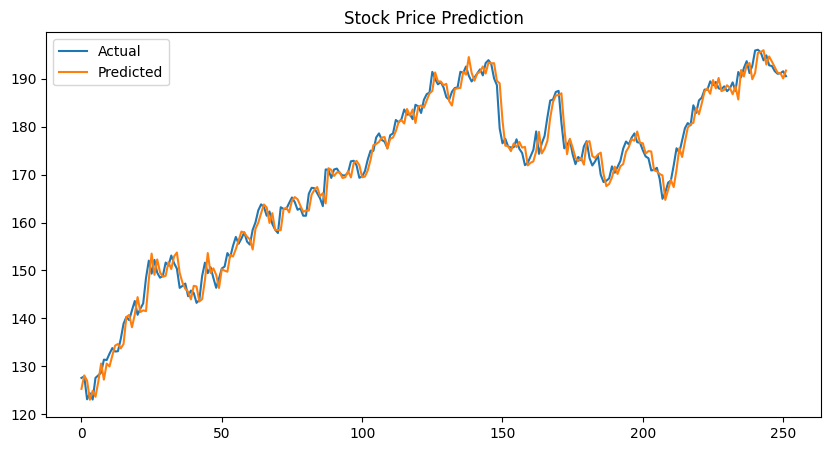

In [31]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [32]:
# Next day prediction
latest = df[['Open','High','Low','Volume']].iloc[-1].values.reshape(1,-1)
next_price = model.predict(latest)
print("Predicted Next Closing Price:", next_price[0])

Predicted Next Closing Price: 191.73517557789083
